In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
plt.rcParams["font.family"]=["SimHei"]
plt.rcParams["axes.unicode_minus"]=False
real_leaf=cv2.imread("leaf.jpg")
print("leaf的尺寸shape为：",real_leaf.shape)

leaf的尺寸shape为： (2048, 1536, 3)


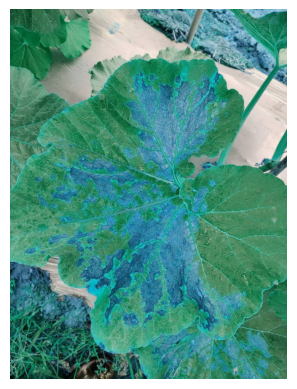

In [2]:
plt.imshow(real_leaf)
plt.axis('off')
plt.show()

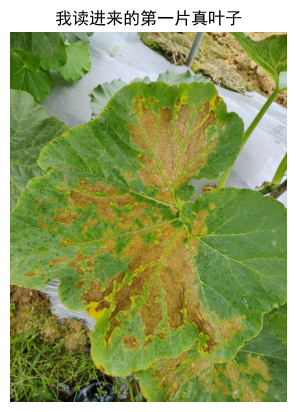

In [3]:
# 把OpenCV的BGR顺序，转成我们习惯的RGB顺序
real_leaf_rgb=cv2.cvtColor(real_leaf,cv2.COLOR_BGR2RGB)
plt.imshow(real_leaf_rgb)
plt.axis('off')
plt.title("我读进来的第一片真叶子")
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

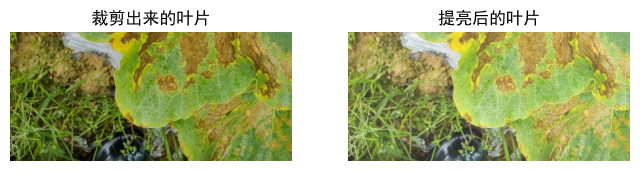

In [4]:
crop_leaf=real_leaf_rgb[1500:3000,0:1200]
crop_leaf_float = crop_leaf.astype(np.float32)
crop_leaf_bright=np.clip(crop_leaf_float + 40,a_min=0,a_max=255)
crop_leaf_bright=crop_leaf_bright.astype(np.uint8)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(crop_leaf)
plt.axis('off')
plt.title("裁剪出来的叶片")

plt.subplot(1,2,2)
plt.imshow(crop_leaf_bright)
plt.title("提亮后的叶片")
plt.axis('off')
plt.show

In [5]:
#下面学习灰度图与图片尺寸缩放
real_leaf=cv2.imread("leaf.jpg")
real_leaf_rgb=cv2.cvtColor(real_leaf,cv2.COLOR_BGR2RGB)
#下面把RGB彩色图转为灰度图
gray_leaf=cv2.cvtColor(real_leaf_rgb,cv2.COLOR_RGB2GRAY)
#打印对比
print("彩色图的尺寸shape:",real_leaf_rgb.shape)
print("灰度图的尺寸shape:",gray_leaf.shape)

彩色图的尺寸shape: (2048, 1536, 3)
灰度图的尺寸shape: (2048, 1536)


In [6]:
#验证一下BGR和RGB转灰度图的灰度值不一样是否成立
print(gray_leaf[1000,1000])
real_leaf2=cv2.imread("leaf.jpg")
gray_leaf2=cv2.cvtColor(real_leaf2,cv2.COLOR_BGR2GRAY)
print(gray_leaf2[1000,1000])

# 自动找全图里R通道和B通道差值最大的像素点
rgb = real_leaf_rgb
# 计算每个像素的R和B通道差值
r_b_diff = np.abs(rgb[:,:,0].astype(int) - rgb[:,:,2].astype(int))
# 找到差值最大的像素坐标
max_diff_pos = np.unravel_index(np.argmax(r_b_diff), r_b_diff.shape)
print(f"R/B通道差最大的像素坐标是：{max_diff_pos}")
print(f"这个像素的RGB值是：{rgb[max_diff_pos[0], max_diff_pos[1]]}")

# 分别用两个规则算这个点的灰度值
gray1 = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(real_leaf, cv2.COLOR_BGR2GRAY)
print(f"用RGB2GRAY算出来的灰度值：{gray1[max_diff_pos[0], max_diff_pos[1]]}")
print(f"用BGR2GRAY算出来的灰度值：{gray2[max_diff_pos[0], max_diff_pos[1]]}")

# 故意把RGB顺序的图，用BGR2GRAY的错误规则转
wrong_gray = cv2.cvtColor(real_leaf_rgb, cv2.COLOR_BGR2GRAY)
# 对比一下正确的灰度值和错配的灰度值
print(f"正确的RGB2GRAY灰度值：{gray1[1000,1000]}")
print(f"错误的BGR2GRAY灰度值：{wrong_gray[1000,1000]}")


126
126
R/B通道差最大的像素坐标是：(np.int64(1574), np.int64(462))
这个像素的RGB值是：[219 201   5]
用RGB2GRAY算出来的灰度值：184
用BGR2GRAY算出来的灰度值：184
正确的RGB2GRAY灰度值：126
错误的BGR2GRAY灰度值：117


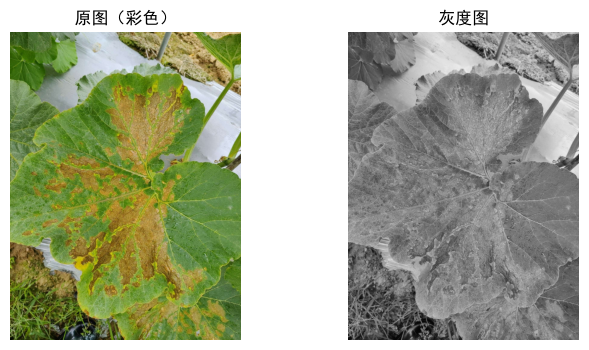

In [7]:
#灰度图是没有颜色的二维数组，matplotlib默认会乱给他上假彩色，必须手动指定黑白色版
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(real_leaf_rgb)
plt.title("原图（彩色）")
plt.axis('off')

plt.subplot(1,2,2)
#这里必须附加cmap='gray'，不然颜色会乱
plt.imshow(gray_leaf,cmap='gray')
plt.title("灰度图")
plt.axis('off')
plt.show()

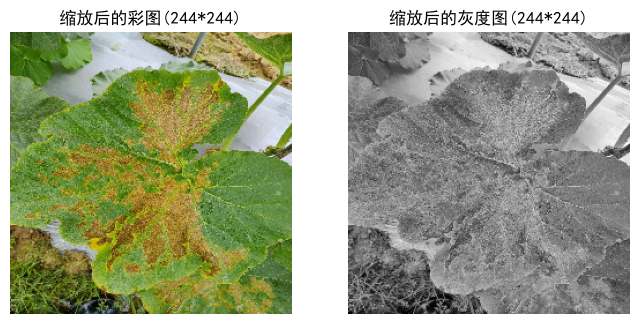

In [8]:
#图片固定尺寸缩放,cv2.resize写新尺寸的顺序是先写宽，再写高
resize_rgb=cv2.resize(real_leaf_rgb,(244,244))
resize_gray=cv2.resize(gray_leaf,(244,244))
#对比显示缩放前后的效果
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(resize_rgb)
plt.title("缩放后的彩图(244*244)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(resize_gray,cmap='gray')
plt.title("缩放后的灰度图(244*244)")
plt.axis('off')
plt.show()

In [9]:
# 打印图片中间叶片区域的灰度值,对比观察
print("叶片位置的灰度值：", resize_gray[140, 32])
# 打印图片背景天空区域的灰度值
print("背景位置的灰度值：", resize_gray[0, 0])


叶片位置的灰度值： 129
背景位置的灰度值： 70


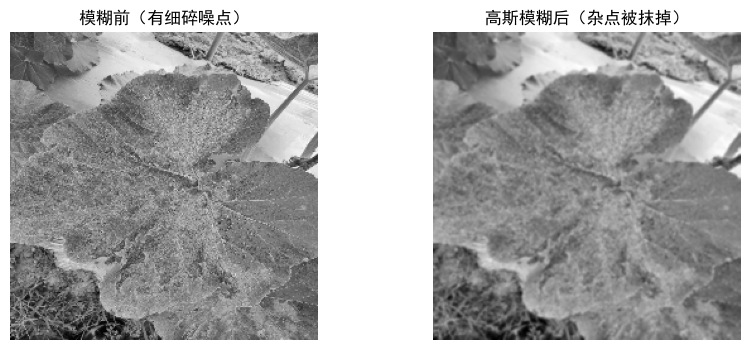

In [10]:
# 高斯模糊：(5,5)是模糊的窗口大小，新手固定用这个值就行
blur_leaf = cv2.GaussianBlur(resize_gray, (3,3), 0)

# 并排显示模糊前后的对比
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(resize_gray, cmap='gray')
plt.title("模糊前（有细碎噪点）")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(blur_leaf, cmap='gray')
plt.title("高斯模糊后（杂点被抹掉）")
plt.axis('off')
plt.show()


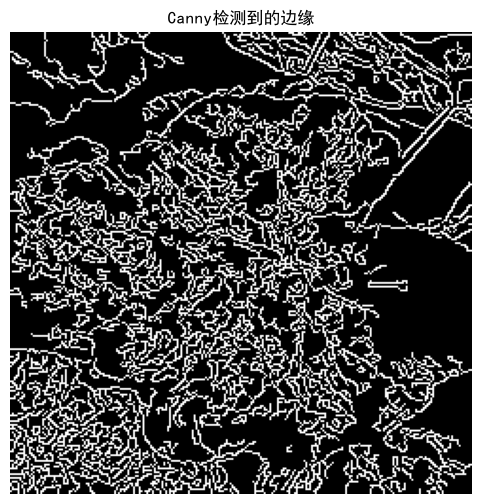

In [11]:
# Canny边缘检测：两个阈值新手固定用50和150就行
edge_leaf = cv2.Canny(blur_leaf, threshold1=50, threshold2=150)

# 显示边缘检测的结果
plt.figure(figsize=(8,6))
plt.imshow(edge_leaf, cmap='gray')
plt.title("Canny检测到的边缘")
plt.axis('off')
plt.show()


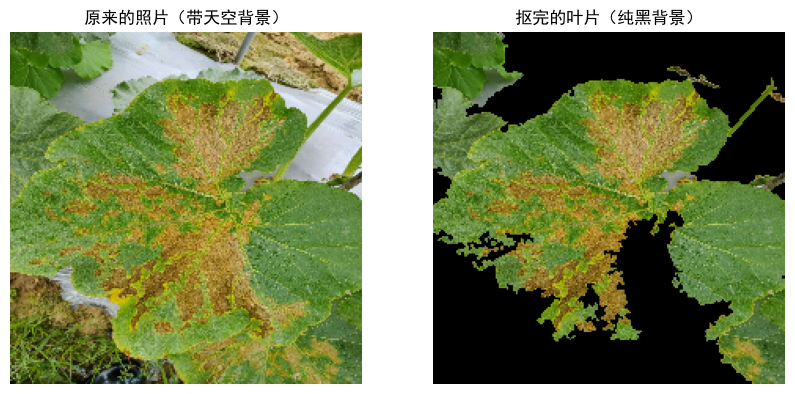

In [ ]:
# 读入原图→转RGB→缩放到224x224
real_leaf = cv2.imread("leaf.jpg")
real_leaf_rgb = cv2.cvtColor(real_leaf, cv2.COLOR_BGR2RGB)
real_leaf_224 = cv2.resize(real_leaf_rgb, (224,224))

# 转灰度→3x3高斯模糊（和上节课的流程完全一致）
gray_leaf_224=cv2.cvtColor(real_leaf_224,cv2.COLOR_RGB2GRAY)
blur_leaf=cv2.GaussianBlur(gray_leaf_224,(3,3),0)
ret,mask=cv2.threshold(blur_leaf,thresh=135,maxval=255,type=cv2.THRESH_BINARY_INV)
contours,hierarchy=cv2.findContours(mask,mode=cv2.RETR_EXTERNAL,method=cv2.CHAIN_APPROX_SIMPLE)
leaf_contour=sorted(contours,key=cv2.contourArea,reverse=True)[0]
leaf_mask=np.zeros_like(gray_leaf_224)
cv2.drawContours(leaf_mask,[leaf_contour],contourIdx=-1,color=255,thickness=-1)
leaf_mask_3ch=cv2.cvtColor(leaf_mask,cv2.COLOR_GRAY2RGB)
leaf_only=(real_leaf_224*(leaf_mask_3ch/255)).astype(np.uint8)

# 并排显示原图和抠完的叶片
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(real_leaf_224)
plt.title("原来的照片（带天空背景）")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(leaf_only)
plt.title("抠完的叶片（纯黑背景）")
plt.axis('off')
plt.show()


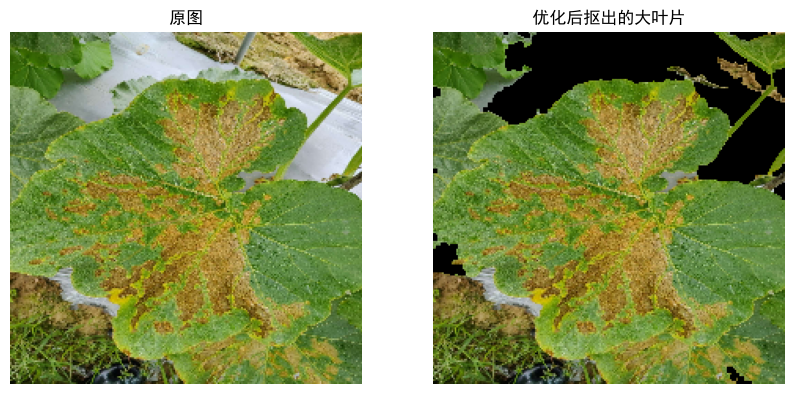

In [24]:
# 前置流程不变
real_leaf = cv2.imread("leaf.jpg")
real_leaf_rgb = cv2.cvtColor(real_leaf, cv2.COLOR_BGR2RGB)
real_leaf_224 = cv2.resize(real_leaf_rgb, (224,224))
gray_leaf_224 = cv2.cvtColor(real_leaf_224, cv2.COLOR_RGB2GRAY)
blur_leaf_224 = cv2.GaussianBlur(gray_leaf_224, (3,3), 0)

# 🔴 核心优化：用OTSU自动找阈值，不用手动写死120
# 算法会自动在图里找最合适的亮暗分界线，不管照片亮度怎么变都能适配
ret, mask = cv2.threshold(blur_leaf_224, thresh=0, maxval=255, 
                          type=cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 🔴 再加一步小操作：把叶片内部病斑的小洞填上
kernel = np.ones((3,3), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# 找所有轮廓，取面积最大的那个——这次肯定是中心的大叶片
contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
leaf_contour = sorted(contours, key=cv2.contourArea, reverse=True)[0]

# 生成干净的叶片蒙版
leaf_mask = np.zeros_like(gray_leaf_224)
cv2.drawContours(leaf_mask, [leaf_contour], -1, 255, -1)

# 把蒙版盖回原图，抠出叶片
leaf_mask_3ch = cv2.cvtColor(leaf_mask, cv2.COLOR_GRAY2RGB)
leaf_only = (real_leaf_224 * (leaf_mask_3ch / 255)).astype(np.uint8)

# 并排显示效果
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(real_leaf_224)
plt.title("原图")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(leaf_only)
plt.title("优化后抠出的大叶片")
plt.axis('off')
plt.show()
